# Dimensionality Reduction

Dimensionality reduction is a technique used in machine learning and statistics to reduce the number of input variables in a dataset. More input features often make a model more complex, increasing the risk of overfitting and making the model harder to interpret. Dimensionality reduction techniques aim to simplify models without losing much information.

---

### Why is Dimensionality Reduction Important?

1. **Simplification**: Makes the dataset easier to explore and visualize.
2. **Speed**: Reduces the computational complexity, making algorithms run faster.
3. **Data Compression**: Allows for more efficient storage of data.
4. **Noise Reduction**: Helps to eliminate irrelevant features or reduce noise.
5. **Improved Performance**: Can lead to better model performance when irrelevant features are removed.

---

### Example: Customer Segmentation in Retail

Imagine you're a data scientist at a retail company. The company collects data on customer transactions, online activity, customer service interactions, and more. In total, you have hundreds of features for each customer.

**The Problem**: You want to segment your customer base to target marketing more effectively, but the high dimensionality of your data makes it difficult to gain any meaningful insights.

**The Solution**: By applying dimensionality reduction techniques like PCA, you can reduce your hundreds of features to just a few principal components. These components can effectively summarize the essential information in the dataset, making it easier to perform customer segmentation.

**Outcome**: The marketing team can now more effectively tailor strategies for different segments, thereby increasing customer engagement and revenue.

## Overview

1. The Curse of Dimensionality
2. PCA
3. Factor Analysis
4. Adaptive Methods: t-SNE and UMAP

---

# The Curse of Dimensionality

 In high dimensions, the behavior of data can be counterintuitive, and algorithms that work well in low dimensions can become ineffective or computationally expensive. This is because the available "space" that training samples are embedded grows exponentially with respect to the data.  This has several ramifications:

 - Distances between items become larger.
 - Differences between distances become smaller.
 - The amount of data required to cover the space grows exponentially.

 See [this explanation](https://www.visiondummy.com/2014/04/curse-dimensionality-affect-classification/) to help guide your intuitions.

### The Hughes Phenomenon ###

In the late 70’s, G. Hughes observed a strange phonomenon while observing large datasets. It is best summarized by the picture below.

![The Hughes Phenomenon](https://ist707.s3.us-east-2.amazonaws.com/assets/hughes-phenomenon.png)

Intuitively, it would be easy to understand that the more inputs (features) you provide the model, the more the predictive power of the model. However, after a certain point the accuracy of the prediction drops off. This is the essence of Hughes Phenomenon. It is based on the fact that measuring data (features or variables) typically has some level of error to it. When you compound this error over a large number of variables, the error explodes so much that the accuracy is affected.

### It Depends!

The curse of dimensionality depends heavily on the distribution of data in a space, the measurements used to calculate distance, and the algorithm applied.  For instance, KNN is highly susceptible to the curse of dimensionality, and Euclidean distances tend to perform worse than either Manhattan or cosine. So, it's always worth exploring your data a little before you decide whether or not to worry about it!

---

### Experiments with dimensionality

The following code illustrates how increasing dimensionality increases distance.

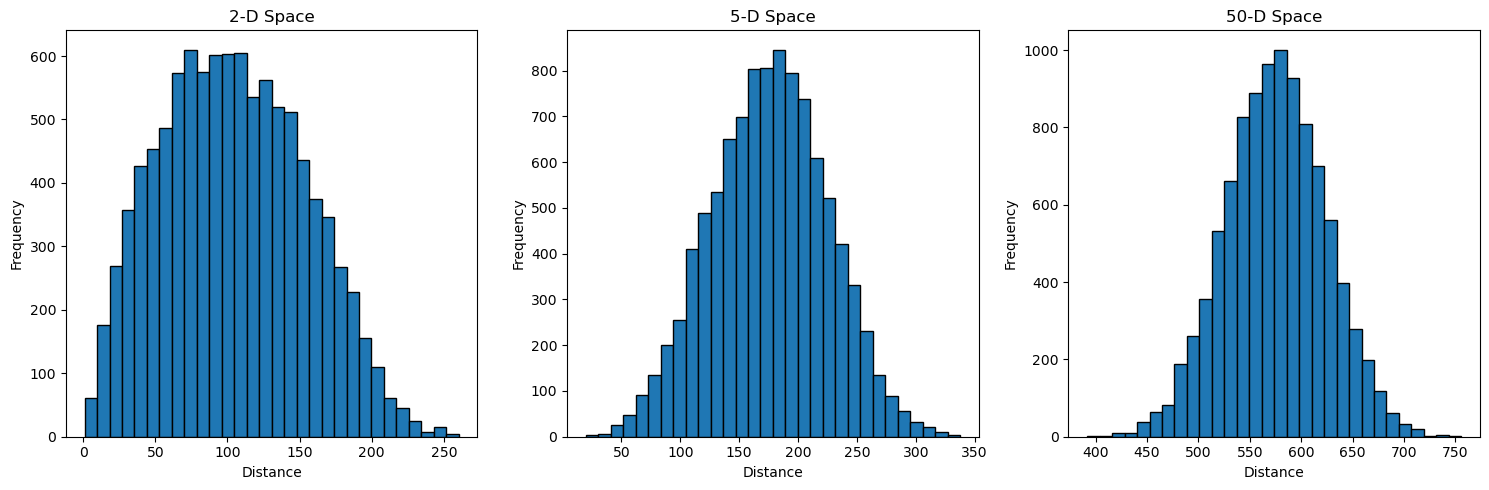

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_points(num_points, num_dimensions):
    return[np.random.randint(-100, 100, num_dimensions) for _ in range(num_points)]

def euclidean_distance(point1, point2):
    return np.sqrt(np.sum((point1 - point2) ** 2))

def compute_pairwise_distances(points_x,points_y):
    distances = []
    for i,j in zip(points_x,points_y):
        distances.append(euclidean_distance(i,j))
    return np.array(distances)

# Set the number of points and dimensions
num_points = 10000

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Loop through a few different dimensions
for ax, num_dimensions in zip(axes, [2, 5, 50]):
    # Generate points in unit hypercube
    points_x = generate_points(num_points, num_dimensions)
    points_y = generate_points(num_points, num_dimensions)

    # Compute pairwise distances
    distances = compute_pairwise_distances(points_x,points_y)

    # Plot histogram of distances
    ax.hist(distances, bins=30, edgecolor='black')
    ax.set_title(f"{num_dimensions}-D Space")
    ax.set_xlabel("Distance")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The three charts show how the distribution of distances between random points changes as the number of dimensions increases. Each subplot corresponds to a different dimensionality: 2‑D, 5‑D, and 50‑D.

Here’s what each chart is illustrating:

⭐ 1. In 2‑D: distances vary widely
In low dimensions, random points can be:

- very close together

- moderately far

- or very far apart

So the histogram is spread out, showing a wide range of distances.

This matches our intuition about points on a plane.

⭐ 2. In 5‑D: distances start to cluster
As dimensionality increases:

- points become more uniformly spread out

- distances become more similar

the histogram becomes narrower and more peaked

This is the beginning of the “concentration of measure” phenomenon.

⭐ 3. In 50‑D: distances are almost all the same
In very high dimensions:

- almost every pair of random points is roughly the same distance apart

- the histogram becomes very tight, with distances concentrated around a single value

This demonstrates a key property of high‑dimensional geometry:

Distances lose contrast — everything becomes equally far apart.

This is why high‑dimensional data is hard for clustering, nearest‑neighbor search, and many ML algorithms.

⭐ Overall takeaway
The charts visualize the classic high‑dimensional effect:

✔ Low dimensions → distances vary
✔ Medium dimensions → distances begin to cluster
✔ High dimensions → distances concentrate around a single value
This is a direct demonstration of the curse of dimensionality.

### Exercise

1. Can you create a loop and evaluate the mean distance for dimensions from 0 - 500?

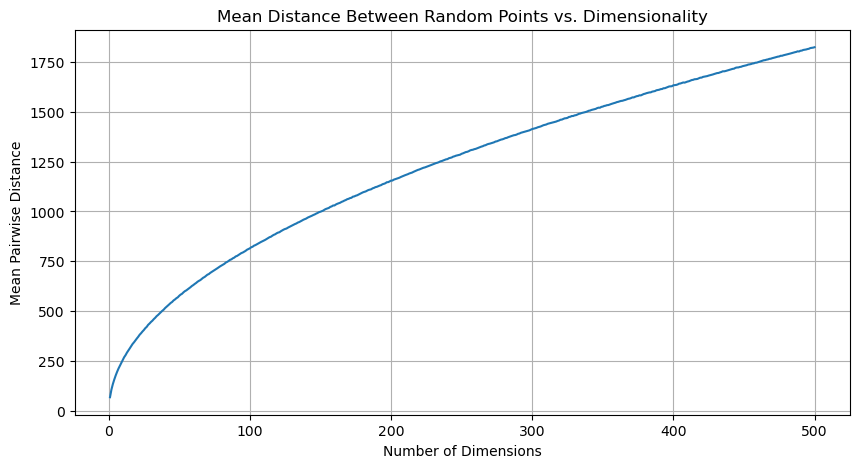

In [2]:
num_points = 5000  # fewer points for speed
max_dim = 500

mean_distances = []

for d in range(1, max_dim + 1):
    points_x = generate_points(num_points, d)
    points_y = generate_points(num_points, d)
    distances = compute_pairwise_distances(points_x, points_y)
    mean_distances.append(distances.mean())

# Plot the mean distance vs. dimension
plt.figure(figsize=(10, 5))
plt.plot(range(1, max_dim + 1), mean_distances)
plt.xlabel("Number of Dimensions")
plt.ylabel("Mean Pairwise Distance")
plt.title("Mean Distance Between Random Points vs. Dimensionality")
plt.grid(True)
plt.show()

As dimensionality increases:

1. Mean distance increases roughly like √d
Because each dimension adds squared differences, the expected distance grows as:

𝐸[∥𝑥−
𝑦
∥
]
∝
𝑑

the  plot will show a smooth, rising curve.

2. Distances become more concentrated
Even though the mean increases, the relative variation shrinks.
In high dimensions, almost all distances cluster tightly around the mean.

3. This demonstrates the curse of dimensionality

- Distances lose contrast

- Nearest and farthest neighbors become indistinguishable

- Many ML algorithms (kNN, clustering) break down

However, observe that the relative differences between max and min in fact approach zero!

C:\Users\gregb\AppData\Local\Temp\ipykernel_18108\406044975.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  delta = (mxd-mnd)/mnd


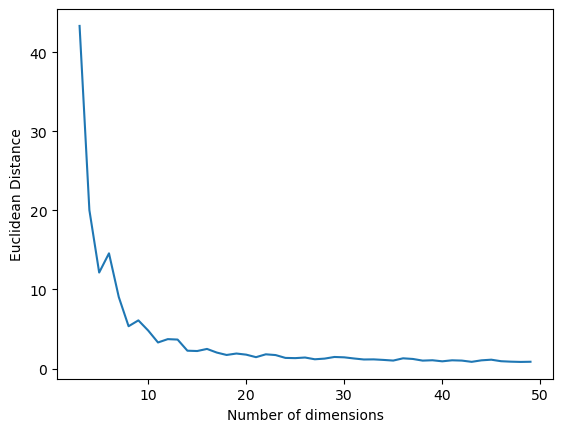

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os
import math

deltas = []
for N in range(2,50):
    # Generate 1000 random points in N dimensions.
    P = [np.random.randint(-100, 100, N) for _ in range(10000)]
    Q = np.random.randint(-100,100, N)
    diffs = [np.linalg.norm(p-Q) for p in P]
    mxd = max(diffs)
    mnd = min(diffs)
    delta = (mxd-mnd)/mnd
    deltas.append( delta )

plt.plot(range(2,50),deltas)
plt.xlabel('Number of dimensions')
plt.ylabel('Euclidean Distance')
plt.show()

---
# Principle Components Analysis (PCA)

One way to reduce dimensionality is a principle components analysis (PCA).  PCA works by performing an eigenvector/eigenvalue decomposition of the data's covariance matrix. The goal is to transform the original features into a new set of uncorrelated features, known as principal components, which capture as much of the data's variance as possible. The first few principal components typically capture the majority of the variance, allowing for a lower-dimensional representation of the data.

### How does it work?

1. Center the data around the origin by subtracting the mean of each feature from the data points.

2. Calculate the covariance matrix, which captures how each feature varies with every other feature.

3. Compute the eigenvalues and eigenvectors of this covariance matrix. An eigenvector of a square matrix $A$ is a non-zero vector $\mathbf{v}$ that, when the matrix multiplies it, only scales the vector and does not change its direction. Mathematically, this can be written as $A\mathbf{v} = \lambda \mathbf{v}$

   Here, $A$ is the square matrix, $\mathbf{v}$ is the eigenvector, and $\lambda$ is the eigenvalue corresponding to this eigenvector. The eigenvalue controls how much the eigenvector is scaled.
   
   **Intuition**: Imagine you have a rubber sheet that you can stretch, compress, or rotate. If you put an arrow (vector) on this sheet and then transform the sheet, most arrows would change both direction and length. However, some special arrows (eigenvectors) would only get "stretched" or "compressed" — they wouldn't change direction. The amount by which they get stretched or compressed is the eigenvalue.

4. Eigenvalues are sorted in descending order, and the eigenvectors are rearranged correspondingly. The first eigenvalue will be the largest and indicates the maximum variance in the data that the first principal component (the corresponding eigenvector) captures.

5. To reduce dimensions, you can now select the first $k$ eigenvectors, where $k$ is the number of dimensions you want in your reduced dataset. You then project your original, centered data into this new \(k\)-dimensional subspace.

6. You can approximate the original data from the reduced data by projecting it back onto the original high-dimensional space by multiplying (dot-product) the transformed data with the transpose of the reduced eigenvector matrix.

### A Simple Example

First, we'll set up some sample data

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 1: Create synthetic 2D data
np.random.seed(0)
X = np.dot(np.random.rand(2, 2), np.random.randn(2, 200)).T

Now, the PCA, and the reconstruction:

In [5]:
# Fit the PCA model to the data X and transform X to its first two principal components
# this does not reduce the dimensions of the data
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Now, reduce the data to 1 dimension then use the inverse_transform
# method to reconstruct the original data from the reduced one-dimensional data
# This attempts to reconstruct the original data based on just the first principal component.
X_reduced = PCA(n_components=1).fit_transform(X)
X_reconstructed = PCA(n_components=1).fit(X).inverse_transform(X_reduced)

Finally, plotting:

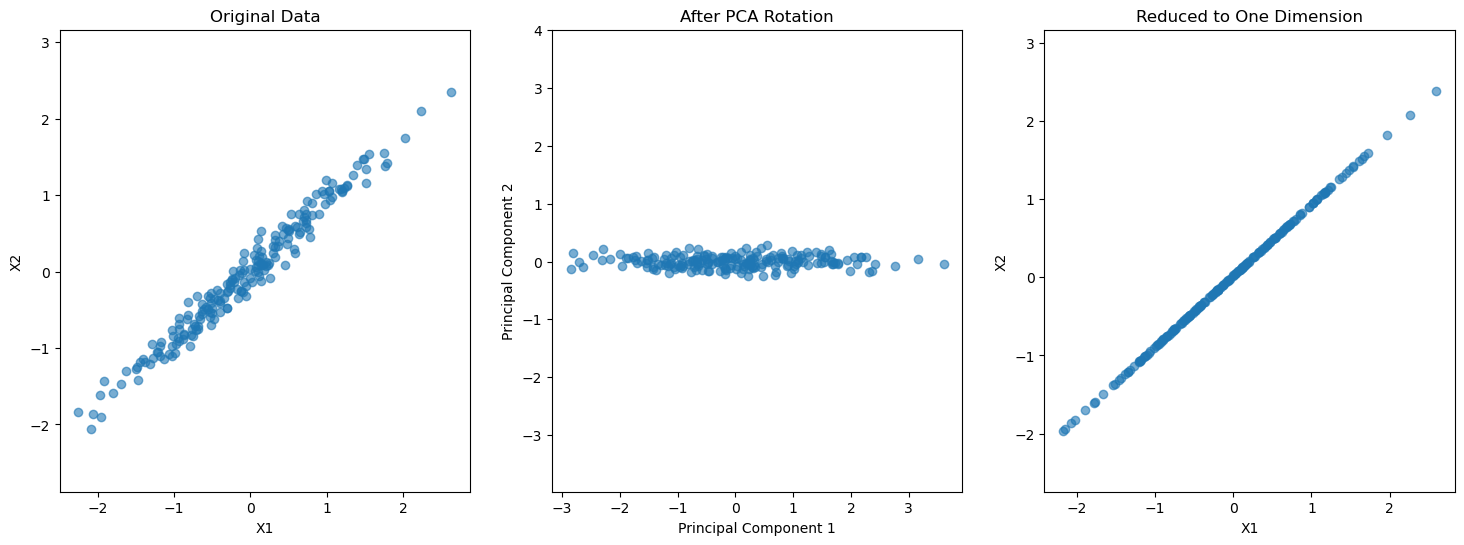

In [6]:
plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.scatter(X[:, 0], X[:, 1], alpha=0.6)
plt.title("Original Data")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')

plt.subplot(1, 3, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.title("After PCA Rotation")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.axis('equal')

plt.subplot(1, 3, 3)
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.6)
plt.title("Reduced to One Dimension")
plt.xlabel("X1")
plt.ylabel("X2")
plt.axis('equal')

plt.show()

Graph 1 — Original Data (Left Plot)
This scatterplot shows the raw 2‑dimensional dataset you generated.

The data is a cloud of points in the original coordinate system.

The axes (X1, X2) are the original features.

There is no rotation, scaling, or transformation applied yet.

This is simply the starting point before PCA does anything.

⭐ Graph 2 — After PCA Rotation (Middle Plot)
This plot shows the same data, but expressed in terms of its principal components.

What PCA does here:

✔ It rotates the coordinate system
The new axes (PC1 and PC2) are aligned with:

PC1: direction of maximum variance

PC2: direction of second‑most variance

✔ No dimensionality reduction happens
You kept n_components=2, so the data is still 2‑D.

✔ The shape of the point cloud is identical
Only the orientation changes.

This plot demonstrates PCA as a rotation into a new basis where the axes capture the most variance.

⭐ Graph 3 — Reduced to One Dimension (Right Plot)
This is the most important plot.

Here’s what happened:

You reduced the data from 2D → 1D using PCA.

You then used inverse_transform to reconstruct the original 2D points from only that single principal component.

What the plot shows:
The reconstructed points lie along a straight line.

That line is the first principal component direction.

All variation along PC2 is lost.

Why?
Because with only one component, PCA can only reconstruct the projection of the data onto PC1.
This is the best 1‑D approximation of the original 2‑D dataset.

Interpretation:
The original 2‑D cloud collapses onto a line.

PCA keeps the direction of greatest variance.

Everything orthogonal to that direction is discarded.

This is a visual demonstration of dimensionality reduction and information loss.

⭐ Summary of What the Three Plots Show

Here’s a clear explanation of what each of the three graphs represents and how they relate to PCA, dimensionality reduction, and reconstruction.

---

# ⭐ **Graph 1 — Original Data (Left Plot)**  
This scatterplot shows the **raw 2‑dimensional dataset** you generated.

- The data is a cloud of points in the original coordinate system.  
- The axes (X1, X2) are the original features.  
- There is no rotation, scaling, or transformation applied yet.

This is simply the starting point before PCA does anything.

---

# ⭐ **Graph 2 — After PCA Rotation (Middle Plot)**  
This plot shows the **same data**, but expressed in terms of its **principal components**.

What PCA does here:

### ✔ It rotates the coordinate system  
The new axes (PC1 and PC2) are aligned with:
- **PC1**: direction of maximum variance  
- **PC2**: direction of second‑most variance  

### ✔ No dimensionality reduction happens  
You kept **n_components=2**, so the data is still 2‑D.

### ✔ The shape of the point cloud is identical  
Only the **orientation** changes.

This plot demonstrates PCA as a **rotation into a new basis** where the axes capture the most variance.

---

# ⭐ **Graph 3 — Reduced to One Dimension (Right Plot)**  
This is the most important plot.

Here’s what happened:

1. You reduced the data from **2D → 1D** using PCA.  
2. You then used `inverse_transform` to **reconstruct** the original 2D points from only that single principal component.

### What the plot shows:

- The reconstructed points lie along a **straight line**.  
- That line is the **first principal component direction**.  
- All variation along PC2 is lost.

### Why?

Because with only **one component**, PCA can only reconstruct the projection of the data onto PC1.  
This is the best 1‑D approximation of the original 2‑D dataset.

### Interpretation:

- The original 2‑D cloud collapses onto a line.  
- PCA keeps the direction of greatest variance.  
- Everything orthogonal to that direction is discarded.

This is a visual demonstration of **dimensionality reduction and information loss**.

---

# ⭐ **Summary of What the Three Plots Show**

| Plot | Meaning | What PCA Did |
|------|---------|--------------|
| **Original Data** | Raw 2‑D points | Nothing |
| **After PCA Rotation** | Same data, new axes aligned with variance | Rotation only |
| **Reduced to One Dimension** | Data projected onto PC1 and reconstructed | Dimensionality reduction + information loss |


### Selecting the right number of components

To select the right number of components, we can use the eigenvalues to calculate the amount of variance explained.  The variance explained by each principal component is directly related to the eigenvalues of the covariance matrix of the original dataset. Specifically, the proportion of variance explained by the $i^{th}$ principal component is given by:

$$
\text{Variance Explained}_i = \frac{\lambda_i}{\sum_{j=1}^{n} \lambda_j}
$$

where $\lambda_i$ is the eigenvalue corresponding to the $i^{th}$ principal component and $n$ is the number of components.

The eigenvalues are stored in decreasing order, and they measure the amount of variance along each principal component. A larger eigenvalue indicates that more variance is explained by that principal component.  We can visualize variance explained using a scree plot, and use the "elbow" method to select the number of components.

Variance Explained per Principal Component: [7.92556233e-01 7.41478585e-02 5.24005453e-02 3.51199136e-02
 2.11433667e-02 1.56168523e-02 4.84778213e-03 2.69208636e-03
 1.29776686e-03 1.77595141e-04]


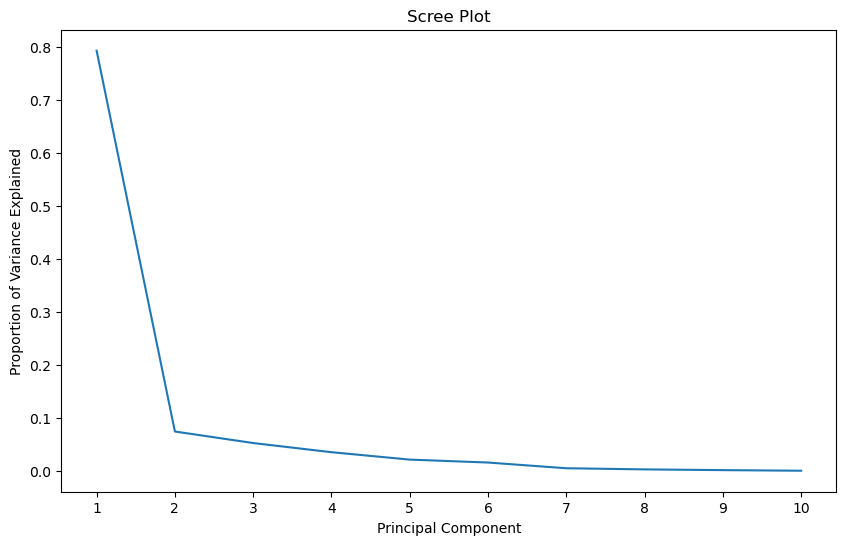

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Step 1: Create synthetic 10D data
np.random.seed(0)
X_high_dim = np.dot(np.random.rand(10, 10), np.random.randn(10, 200)).T

# Step 2: Apply PCA
pca_high_dim = PCA()  # although you can specify n_components, leaving out this parameter returns all
X_pca_high_dim = pca_high_dim.fit_transform(X_high_dim)

# Step 3: Calculate Variance Explained
variance_explained = pca_high_dim.explained_variance_ratio_
print("Variance Explained per Principal Component:", variance_explained)

# Step 4: Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variance_explained) + 1), variance_explained)
plt.xlabel('Principal Component')
plt.ylabel('Proportion of Variance Explained')
plt.title('Scree Plot')
plt.xticks(range(1, len(variance_explained) + 1))
plt.show()

A scree plot is all about showing how much variance each principal component captures, and your code produces a textbook example of what that looks like for synthetic 10‑dimensional data.

Here’s what the plot is telling you.

⭐ What the Scree Plot Shows
1. Each point on the plot represents one principal component
PC1 (the first point) explains the most variance in the dataset.

PC2 explains the next most.

And so on, down to PC10, which explains the least.

Because PCA orders components by variance, the curve always slopes downward.

⭐ 2. The height of each point = proportion of total variance explained
If PC1 has a value of 0.45, that means:

PC1 alone captures 45% of all the structure in the data.

The sum of all 10 values equals 1.0 (100% of the variance).

⭐ 3. The shape of the curve tells you how many components matter
This is the whole purpose of a scree plot.

You typically look for:

✔ A steep drop at the beginning
This means the first few components capture most of the meaningful structure.

✔ A flattening “elbow”
After this point, additional components add very little new information.

✔ A long flat tail
These components mostly represent noise.

For synthetic random data like yours, the curve often decreases gradually without a dramatic elbow, because the variance is spread somewhat evenly across dimensions.

⭐ 4. Interpretation for your specific dataset
Since the data is generated from random linear combinations of Gaussian variables:

PC1 will usually capture noticeably more variance than the others.

The remaining components will decline but not drop to zero.

There may not be a sharp elbow, because the data does not have strong low‑dimensional structure.

This is typical for high‑dimensional random data.

⭐ Summary (one sentence)
The scree plot shows how much variance each principal component captures in your 10‑dimensional dataset, revealing that the first few components explain the most structure while later components contribute progressively less.

Alternatively, if you know how much variance you want to explain, you can easily calculate it like this:

In [8]:
# Calculate cumulative variance explained
cumulative_variance_explained = np.cumsum(pca_high_dim.explained_variance_ratio_)

# Find the number of components for desired explained variance
threshold = 0.95  # 95% variance
n_components = np.argmax(cumulative_variance_explained >= threshold) + 1
print(f"Number of components needed for {threshold*100}% variance: {n_components}")

Number of components needed for 95.0% variance: 4


Scikit-Learn also let's you specify the variance you want in advance and will automatically lift out the number of components you need, as long as your svd_solver is "full".

In [9]:
pca_high_dim = PCA(threshold)  # although you can specify n_components, leaving out this parameter returns all
X_pca_high_dim_auto = pca_high_dim.fit_transform(X_high_dim)

print(f"Number of components retrieved for {threshold*100}% = {X_pca_high_dim_auto.shape[1]}")

Number of components retrieved for 95.0% = 4


## Exercise 2

The MNIST data contains a large sample of handwritten letters.  Each letter is a 28x28 (768) grid of pixels, so the data is quite high dimensional.  Try using PCA to visualize the data.  I'll get you started with a little code below/

In [10]:
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Load MNIST data
mnist = fetch_openml("mnist_784", version=1, parser="auto")
X, y = mnist["data"].values, mnist["target"].astype(int).values

# Sample the dataset to speed up computation (Optional)
X, y = X[:7000], y[:7000]

# Split the dataset
X_mnist_train, X_mnist_test, y_mnist_train, y_mnist_test = train_test_split(X, y, test_size=0.2, random_state=42)


Text(0, 0.5, 'Principal Component 2')

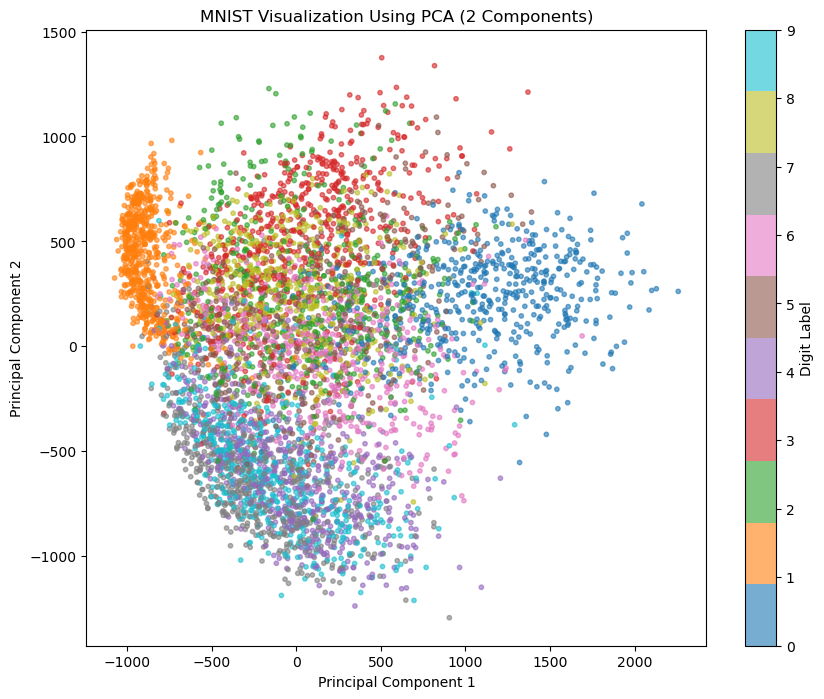

In [12]:
# Step 2: Visualize using PCA (2 components)

# Reduce the data with PCA

# You need to populate the following variable
pca_2d = PCA(n_components=2)
X_mnist_reduced = pca_2d.fit_transform(X_mnist_train)

# Step 6: Plot the 2D PCA projection
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_mnist_reduced [:, 0],
    X_mnist_reduced [:, 1],
    c=y_mnist_train,
    cmap="tab10",
    alpha=0.6,
    s=10
)

plt.colorbar(scatter, label="Digit Label")
plt.title("MNIST Visualization Using PCA (2 Components)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

What the PCA Visualization Shows
1. Each point is a handwritten digit
The original MNIST images are 28×28 = 784‑dimensional.

PCA compresses them into 2 dimensions so we can plot them.

2. Colors represent digit labels (0–9)
Digits with similar shapes tend to cluster together.

3. Some digits form clear clusters
0, 1, and 7 often form tight, distinct groups.

These digits have very consistent shapes.

4. Some digits overlap heavily
3, 5, and 8 often overlap because they share visual similarities.

PCA is linear, so it cannot fully separate complex shapes.

5. The plot reveals structure in the data
Even though PCA is a simple linear method, it still captures:

variation in stroke thickness

roundness vs. straightness

symmetry

overall shape differences

This is why digits naturally form clusters.

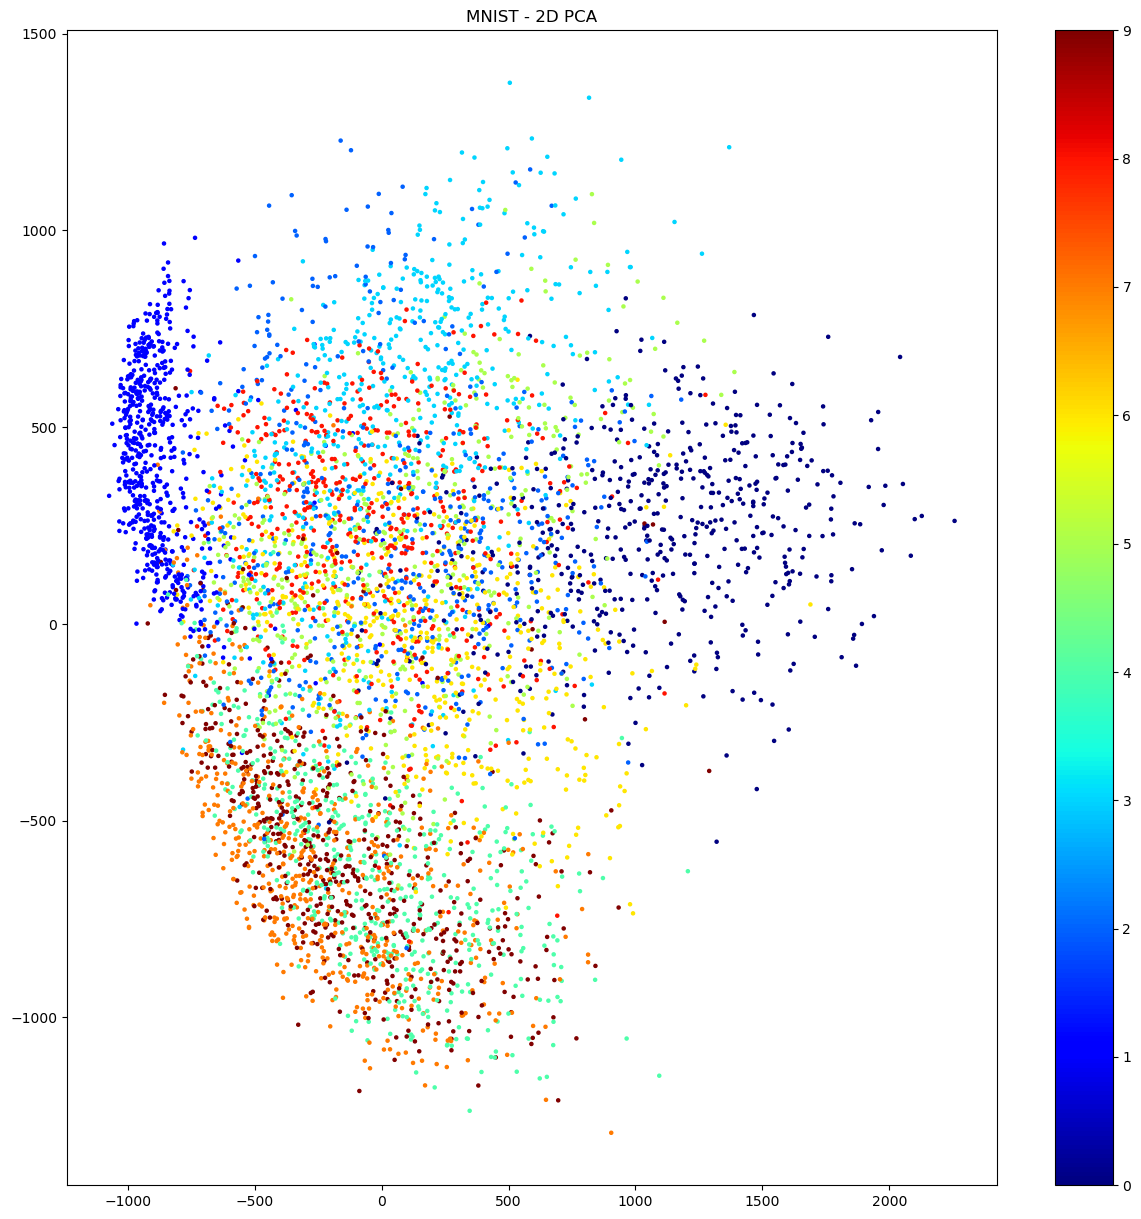

In [13]:
# Now plotting
plt.figure(figsize=(15,15))
plt.scatter(X_mnist_reduced[:, 0], X_mnist_reduced[:, 1], c=y_mnist_train, cmap="jet",s=5)
plt.colorbar()
plt.title("MNIST - 2D PCA")
plt.show()

Now the scree plot...

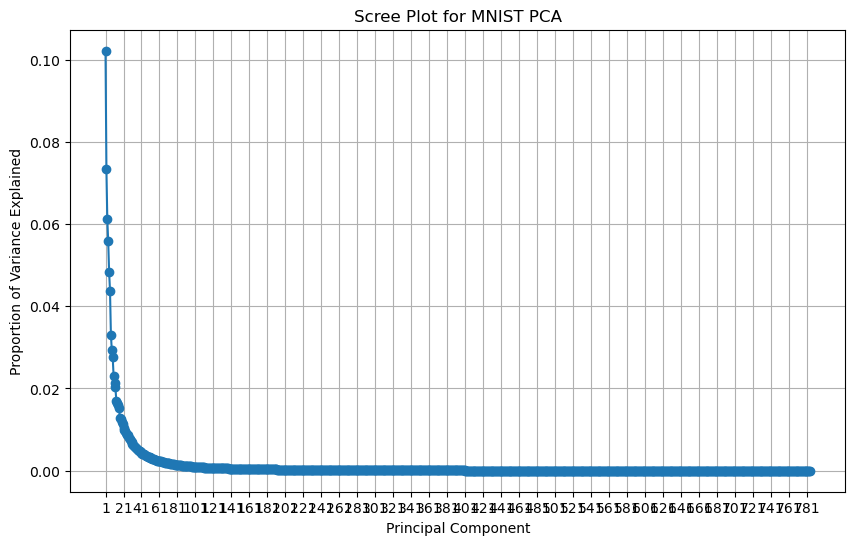

In [15]:
# Step 3: Scree Plot

# Step 1: Fit PCA on the training data (all components)
pca_full = PCA()
pca_full.fit(X_mnist_train)

# Step 2: Extract variance explained
variance_explained = pca_full.explained_variance_ratio_

# Step 3: Plot the scree plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(variance_explained) + 1), variance_explained, marker='o')
plt.title("Scree Plot for MNIST PCA")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.xticks(range(1, len(variance_explained) + 1, 20))  # show fewer ticks for readability
plt.grid(True)
plt.show()


Choose the number of components to achieve 95% variance:

In [16]:
# Step 4: Number of components for 95% variance
threshold = 0.95

# Compute cumulative variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components needed for 95% variance
n_components = np.argmax(cumulative_variance >= threshold) + 1

print(f"Number of components for {threshold*100}% variance: {n_components}")

Number of components for 95.0% variance: 148


It's interesting to look at how a transform and reconstruction affects a single MNIST digit.  I've written a function to display a single digit.  Use PCA and the reconstruction method to have a look at this.  

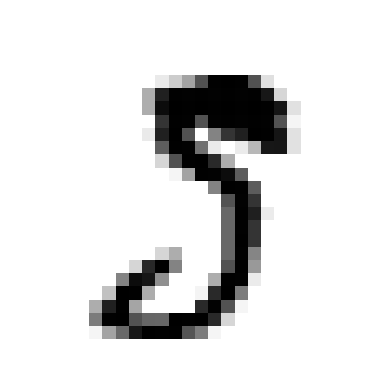

In [17]:
def plot_mnist_digit(digit):
    """Plot a single MNIST digit.

    Parameters:
    digit (numpy array): A flattened 1D numpy array of length 784.

    """
    # Reshape the flattened digit to 28x28 image
    digit_image = digit.reshape(28, 28)

    plt.imshow(digit_image, cmap='binary')
    plt.axis("off")
    plt.show()

plot_mnist_digit(X_mnist_train[0])

In [ ]:
# Use PCA with n_components to transform the above digit.  How does it look?

Use `n_components` to train a `KNNClassifier`, and compare accuracy to the non-reduced data.

Original Data Accuracy: 0.9421428571428572


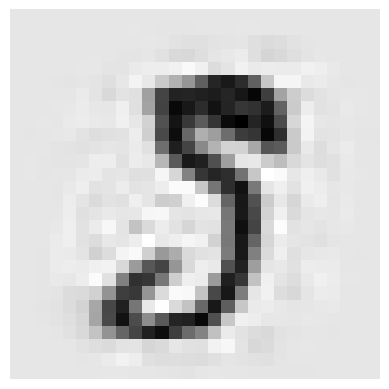

In [24]:
# Step 5: k-NN Classification
# Without PCA
knn = KNeighborsClassifier()
knn.fit(X_mnist_train, y_mnist_train)
y_pred = knn.predict(X_mnist_test)
acc = accuracy_score(y_mnist_test, y_pred)
print(f"Original Data Accuracy: {acc}")

# With PCA
# You have some work to do right here
# Choose number of PCA components
pca = PCA(n_components=n_components)   # <-- you can change this number

# Fit PCA on the training data
pca.fit(X_mnist_train)

# Transform the entire training set
X_mnist_reduced = pca.transform(X_mnist_train)

# Take one digit
digit = X_mnist_train[0]

# Transform to PCA space
digit_reduced = pca.transform([digit])

# Reconstruct back to 784 pixels
digit_reconstructed = pca.inverse_transform(digit_reduced)

# Visualize the reconstructed digit
plot_mnist_digit(digit_reconstructed[0])
#y_pred_pca = None # How do you do this?
#print(f"PCA-transformed Data Accuracy: {accuracy_score(y_mnist_test, y_pred_pca)}")


---

## Limitations of PCA

One of the key limitations of PCA is that it is a linear technique. This means that it works by finding new axes, called principal components, that are linear combinations of the original features. These principal components aim to capture as much variance in the data as possible. However, the linear nature of PCA imposes a limitation: it struggles to capture patterns in data that are fundamentally non-linear.

Imagine a dataset where points are distributed in a non-linear fashion, like a spiral or concentric circles. A linear method like PCA would not be able to capture the essence of such patterns. This is because the concept of "distance" or "variance" that PCA relies on does not adequately describe the intrinsic geometry of the data.

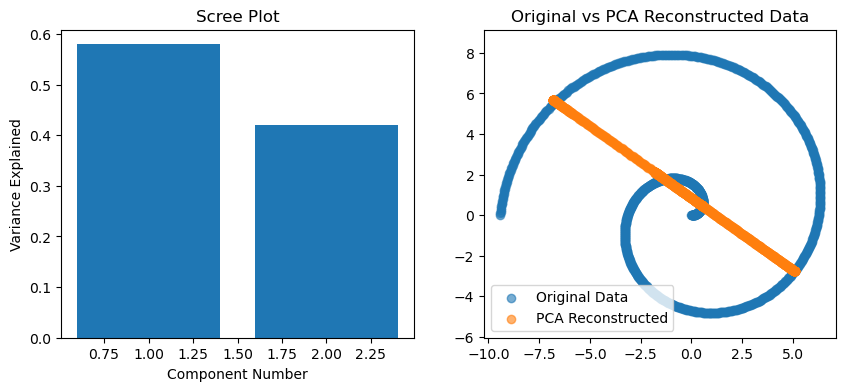

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Generate synthetic spiral data
n_points = 1000
n_turns = 3
t = np.linspace(0, n_turns * np.pi, n_points)
x = t * np.cos(t)
y = t * np.sin(t)

X_spiral = np.column_stack([x, y])

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_spiral)

# Scree Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_)
plt.title("Scree Plot")
plt.xlabel("Component Number")
plt.ylabel("Variance Explained")

# Original Data vs PCA reconstruction
X_reduced = PCA(n_components=1).fit_transform(X_spiral)
X_reconstructed = PCA(n_components=1).fit(X_spiral).inverse_transform(X_reduced)

plt.subplot(1, 2, 2)
plt.scatter(X_spiral[:, 0], X_spiral[:, 1], alpha=0.6, label='Original Data')
plt.scatter(X_reconstructed[:, 0], X_reconstructed[:, 1], alpha=0.6, label='PCA Reconstructed')
plt.legend()
plt.axis('equal')
plt.title("Original vs PCA Reconstructed Data")

plt.show()


⭐ Chart 1 — Scree Plot (Left Plot)
The scree plot shows how much variance each principal component explains.

Since your spiral dataset is 2‑dimensional, PCA produces exactly two components:

PC1 explains most of the variance  
This is because the spiral stretches outward, and the longest direction of variation is along the spiral’s overall radius.

PC2 explains the remaining variance  
This captures the smaller, orthogonal variations — the twisting of the spiral.

What the bar heights mean
The first bar is tall → PC1 captures the majority of the structure.

The second bar is shorter → PC2 captures the leftover curvature.

This tells you that the spiral is not well‑represented by a single linear direction, but PCA still finds one dominant axis.

⭐ Chart 2 — Original vs PCA‑Reconstructed Data (Right Plot)
This plot compares:

Original spiral (blue points)

Reconstructed spiral using only 1 PCA component (orange points)

What happens when PCA reduces the spiral to 1 dimension?
PCA projects the spiral onto a straight line (the first principal component), then reconstructs it back into 2D.

Because PCA is linear, it cannot preserve the spiral’s curved shape.

What the chart shows:
The original spiral is clearly visible — a smooth, outward‑winding curve.

The reconstructed points lie along a straight line through the center.

The spiral structure is completely lost.

Why?
Because PCA with 1 component keeps only the largest direction of variance, which is roughly the outward radial direction.
All the twisting (the nonlinear structure) is discarded.

This demonstrates a key limitation:

PCA cannot capture nonlinear shapes like spirals.

| Chart | What It Shows | Key Insight |
| --- | --- | --- |
| **Scree Plot** | Variance explained by PC1 and PC2 | PC1 dominates, but PC2 still matters because the spiral is curved |
| **Original vs Reconstructed** | How the spiral collapses when reduced to 1D | PCA cannot preserve nonlinear structure; the spiral becomes a straight line |

---

# Other Approaches

There are many many approach to dimesionality reduction. Several extensions to PCA address its limitations and extend its capabilities. One of these is **Kernel PCA**.

### Kernel PCA

Kernel Principal Component Analysis (Kernel PCA) is an extension of the standard Principal Component Analysis (PCA), designed to handle non-linear data effectively. While standard PCA works by finding linear principal components to project data onto, Kernel PCA works in an implicitly defined higher-dimensional feature space where these projections can be non-linear.

### How Kernel PCA Works

1. **Feature Space Mapping**: First, each data point in the original space is mapped into a higher-dimensional feature space using a kernel function $K(x_i, x_j)$. These are the same as with **Support Vector Machines**.

2. **Principal Component Analysis in Feature Space**: In this new feature space, the regular PCA algorithm is applied. Since working in a higher-dimensional space can be computationally intensive, Kernel PCA cleverly utilizes the "kernel trick" to compute principal components in the feature space without explicitly working in it.

3. **Projecting Data**: Finally, the original data is projected onto these new principal components in the feature space. The resulting data can be linearly separable even if the original data was not.

### Kernel Functions

Kernel PCA relies on the use of a kernel function to compute the similarity between pairs of data points in the feature space. Popular choices for kernel functions include:

- **Polynomial Kernel**: $K(x_i, x_j) = (x_i \cdot x_j + c)^d$
- **RBF (Radial Basis Function) or Gaussian Kernel**: $K(x_i, x_j) = \exp(-\gamma ||x_i - x_j||^2)$
- **Sigmoid Kernel**: $K(x_i, x_j) = \tanh(\alpha x_i \cdot x_j + c)$

### Advantages and Limitations

#### Advantages
- Can capture complex, non-linear relationships in data.
- Suitable for clustering, classification, and other tasks where linear methods fail.

#### Limitations
- Computationally more expensive compared to standard PCA.
- Requires choosing an appropriate kernel function and tuning its parameters, which may not be straightforward.

#### Example

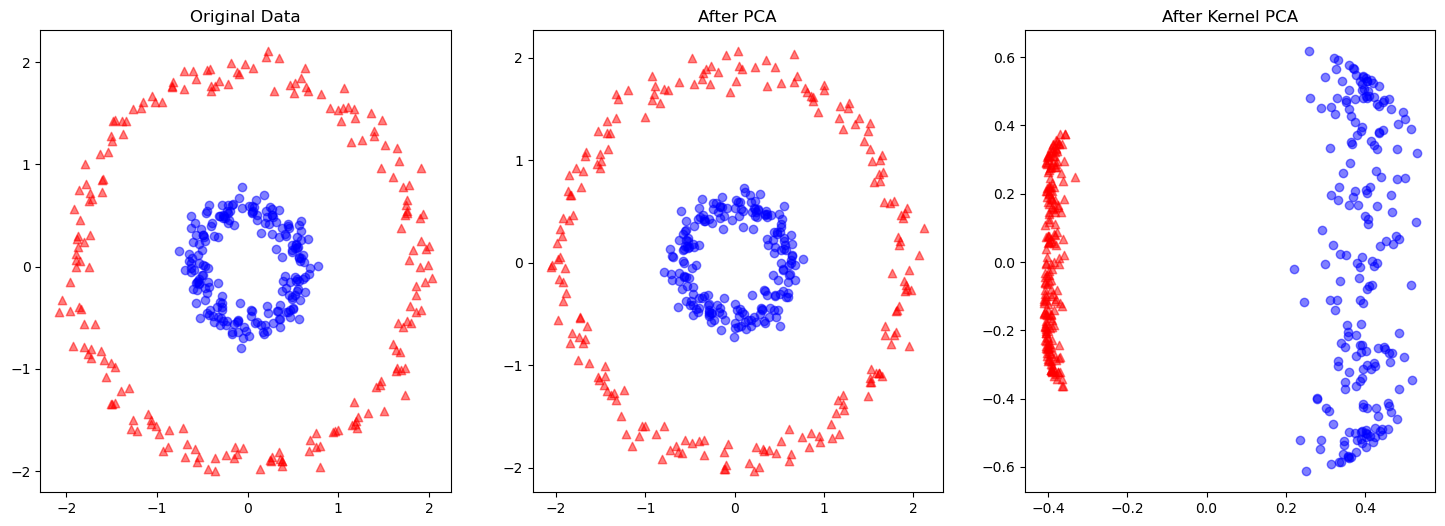

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.decomposition import KernelPCA, PCA
from sklearn.preprocessing import StandardScaler

# Generate synthetic data for concentric circles
np.random.seed(0)
X, y = make_circles(n_samples=400, factor=.3, noise=.05)

# Standardize the data
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

# Apply regular PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

# Apply Kernel PCA with Radial Basis Function (RBF) kernel
kpca = KernelPCA(kernel="rbf", gamma=1, n_components=2)
X_kpca = kpca.fit_transform(X_std)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot original data
axes[0].scatter(X_std[y == 0, 0], X_std[y == 0, 1], color='red', marker='^', alpha=0.5)
axes[0].scatter(X_std[y == 1, 0], X_std[y == 1, 1], color='blue', marker='o', alpha=0.5)
axes[0].set_title("Original Data")

# Plot data transformed by PCA
axes[1].scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], color='red', marker='^', alpha=0.5)
axes[1].scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], color='blue', marker='o', alpha=0.5)
axes[1].set_title("After PCA")

# Plot data transformed by Kernel PCA
axes[2].scatter(X_kpca[y == 0, 0], X_kpca[y == 0, 1], color='red', marker='^', alpha=0.5)
axes[2].scatter(X_kpca[y == 1, 0], X_kpca[y == 1, 1], color='blue', marker='o', alpha=0.5)
axes[2].set_title("After Kernel PCA")

plt.show()

⭐ Chart 1 — Original Data (Left Plot)
This plot shows the raw concentric circles dataset after standardization.

What you see:
Red triangles = inner circle

Blue circles = outer circle

The two classes are not linearly separable — no straight line can separate them.

Key insight:
This dataset is intentionally designed to break linear methods like PCA.
The structure is nonlinear, and the classes are intertwined in a circular pattern.

⭐ Chart 2 — After PCA (Middle Plot)
This plot shows the data after applying standard (linear) PCA.

What PCA does:
PCA finds directions of maximum variance.

It performs a linear rotation of the data.

It cannot “unwrap” or separate nonlinear shapes.

What the plot shows:
The two circles are still overlapping.

PCA collapses the circular structure into an elongated blob.

The classes remain mixed together, offering no separation.

Key insight:
PCA fails on nonlinear datasets because it can only capture linear structure.

⭐ Chart 3 — After Kernel PCA (Right Plot)
This plot shows the data transformed using Kernel PCA with an RBF kernel, which can capture nonlinear structure.

What Kernel PCA does:
Uses a nonlinear kernel (RBF) to project the data into a higher‑dimensional feature space.

In that space, the circles become linearly separable.

Then PCA is applied in that transformed space.

What the plot shows:
The two classes are now clearly separated.

The inner and outer circles become distinct clusters.

The nonlinear structure is successfully “unwrapped.”

Key insight:
Kernel PCA can separate nonlinear patterns that regular PCA cannot.

This is the classic demonstration of why kernel methods are powerful.

| Chart | What It Shows | Key Takeaway |
| --- | --- | --- |
| **Original Data** | Two concentric circles | Nonlinear structure, not linearly separable |
| **After PCA** | Overlapping clusters | PCA fails because it is linear |
| **After Kernel PCA** | Clear separation of classes | Kernel PCA captures nonlinear structure |

# Adaptive Techniques

Adaptive techniques seek to preserve complex, non-linear relationships between data points. Unlike linear methods like PCA, which apply a rigid transformation to all points in the dataset equally, adaptive methods tweak and optimize the transformation for different regions of the data space. In simpler terms, they adapt to the underlying data distribution.

This adaptability often makes these techniques more suitable for capturing and preserving intricate structures in high-dimensional data, such as clusters or manifolds.  However, they are often stochastic and are not guaranteed to preserve distances in the transformed data, so may not be suitable in all cases.  They are, however, excellent for visualization and some kinds of classification problems.


## t-SNE (t-Distributed Stochastic Neighbor Embedding)

t-SNE is particularly effective for visualizing high-dimensional data in 2D or 3D.

#### How it Works:

1. **Probability Distributions**: t-SNE starts by calculating the pairwise similarities between points in the high-dimensional space and in the low-dimensional space. These similarities are converted into conditional probabilities that a point would pick another point as its neighbor if neighbors were picked in proportion to their similarity.

2. **Minimize the Divergence**: t-SNE aims to minimize the difference between these two probability distributions for the high-dimensional and low-dimensional spaces. Specifically, it minimizes the Kullback-Leibler divergence between them.

3. **t-Distribution**: To calculate the similarity between points in the low-dimensional space, t-SNE uses a t-distribution, which has heavier tails compared to a normal distribution. This allows t-SNE to be particularly sensitive to local structures.

#### Strengths:

- Excellent at preserving local cluster structures.
- Particularly useful for visualization.

#### Weaknesses:

- Computationally intensive.
- May not preserve global structures well.
- The results are sensitive to hyperparameters like perplexity and the learning rate.
- **IMPORTANT** t-SNE does not enable "training" - you cannot fit a model and then apply it to new data. As a result, it is not really appopriate for train/test scenarios.

t-SNE has been a popular choice for tasks like visualizing gene expression data, understanding neural network activations, clustering, and much more.

With t-SNE, it's easier to capture the non-linear manifolds and groupings in data, making it an excellent tool for exploratory data analysis. However, because it's computationally demanding and somewhat unpredictable, it may not always be the best choice for all types of dimensionality reduction tasks.

---

### Example

A classic example of data that PCA struggles with is the `swiss roll`, which you can envision as a sheet of paper rolled into a tube.  You'll see the PCA manages to uncover the spiral, but not it's "sheet-like" properties.

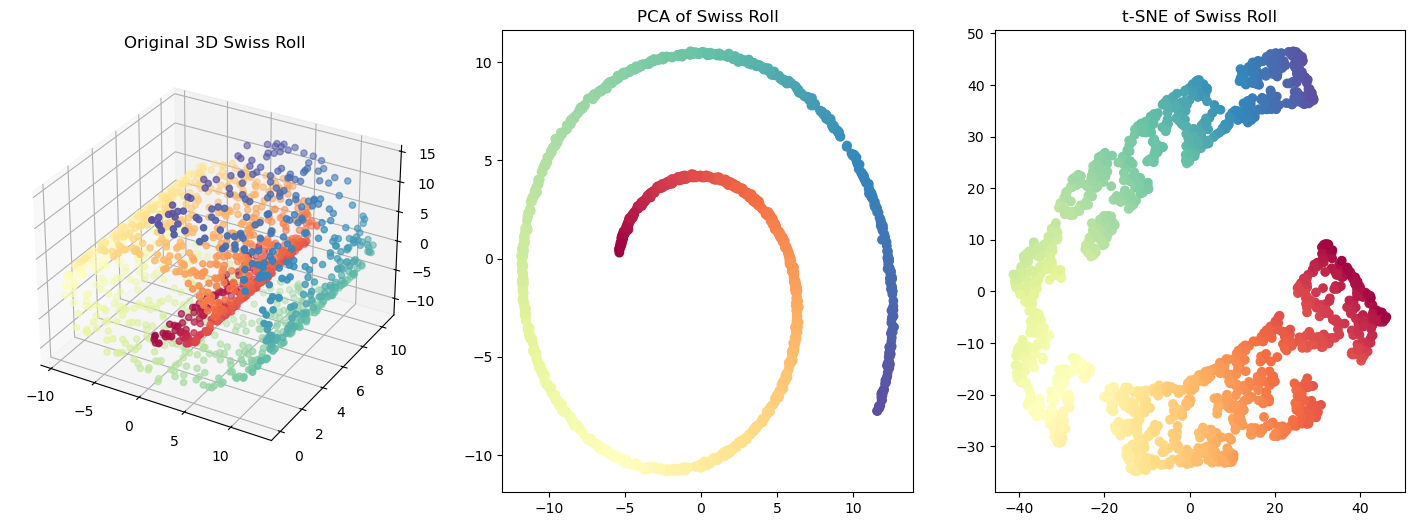

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.datasets import make_swiss_roll
from mpl_toolkits.mplot3d import Axes3D

import os
os.environ["LOKY_MAX_CPU_COUNT"] = "8"   # replace 8 with your number of cores

# Create Swiss Roll data
n_samples = 1500
noise = 0.05
X, color = make_swiss_roll(n_samples, noise=noise)
# Make it thinner
X[:, 1] *= .5

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=0)
X_tsne = tsne.fit_transform(X)

# Visualization
fig = plt.figure(figsize=(18, 6))

# 3D Swiss Roll
ax0 = fig.add_subplot(131, projection='3d')
ax0.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)
ax0.set_title("Original 3D Swiss Roll")

# PCA
ax1 = fig.add_subplot(132)
ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=color, cmap=plt.cm.Spectral)
ax1.set_title("PCA of Swiss Roll")

# t-SNE
ax2 = fig.add_subplot(133)
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, cmap=plt.cm.Spectral)
ax2.set_title("t-SNE of Swiss Roll")

plt.show()

⭐ Chart 1 — Original 3D Swiss Roll (Left Plot)
This is the true structure of the dataset.

What you see:
A long strip of points curled into a spiral in 3D space.

Colors represent each point’s position along the roll (the “height” of the strip).

The structure is nonlinear and intrinsically 2‑dimensional, but embedded in 3D.

Key insight:
The Swiss Roll is a classic example of a nonlinear manifold.
Any good dimensionality‑reduction method should try to “unroll” it.

⭐ Chart 2 — PCA of Swiss Roll (Middle Plot)
This plot shows the result of applying linear PCA to the 3D data.

What PCA does:
Finds the directions of maximum variance.

Performs a linear projection into 2D.

Cannot “unroll” curved structures.

What the plot shows:
The roll collapses into a flattened, overlapping blob.

Points that were far apart along the spiral become mixed together.

The color gradient is jumbled — the structure is not preserved.

Key insight:
PCA fails on nonlinear manifolds because it can only capture linear structure.

The Swiss Roll is curved, so PCA cannot unfold it.

⭐ Chart 3 — t‑SNE of Swiss Roll (Right Plot)
This plot shows the result of applying t‑SNE, a nonlinear dimensionality‑reduction method.

What t‑SNE does:
Preserves local neighborhoods.

Captures nonlinear structure.

Unrolls the manifold into a meaningful 2D layout.

What the plot shows:
The Swiss Roll is successfully unrolled into a long, smooth strip.

The color gradient flows naturally from one end to the other.

Points that were neighbors in 3D remain neighbors in 2D.

Key insight:
t‑SNE reveals the true underlying 2D structure of the Swiss Roll, unlike PCA.

This is why t‑SNE is widely used for visualizing complex, high‑dimensional datasets.
    
| Chart | What It Shows | Key Takeaway |
| --- | --- | --- |
| **Original 3D Swiss Roll** | True nonlinear 3D manifold | Data is curved and intrinsically 2‑D |
| **PCA** | Linear projection | PCA collapses and distorts the structure |
| **t‑SNE** | Nonlinear embedding | t‑SNE unrolls the manifold and preserves neighborhoods |

## Exercise 3

Try using t-SNE to visualize the MNIST data above.  How does it compare to PCA?

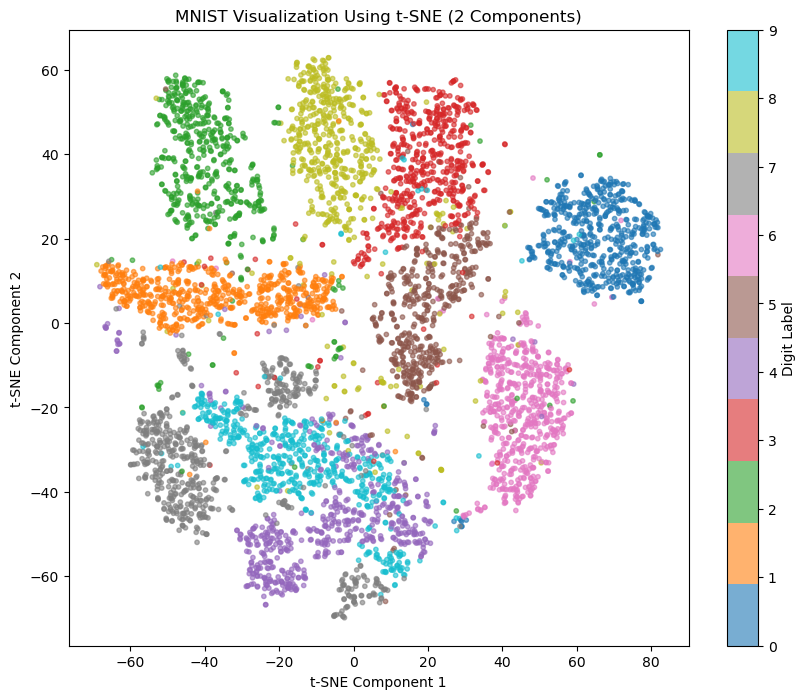

In [29]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Run t-SNE on the training set
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_mnist_tsne = tsne.fit_transform(X_mnist_train)

# Plot the t-SNE embedding
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    X_mnist_tsne[:, 0],
    X_mnist_tsne[:, 1],
    c=y_mnist_train,
    cmap="tab10",
    alpha=0.6,
    s=10
)

plt.colorbar(scatter, label="Digit Label")
plt.title("MNIST Visualization Using t-SNE (2 Components)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()

⭐ How t‑SNE compares to PCA
✔ t‑SNE produces tight, well‑separated clusters
Digits like 0, 1, 4, 7 form distinct islands.
Even confusing digits (3 vs 5, 8 vs 9) separate better than PCA.

✔ PCA produces overlapping blobs
Because PCA is linear, it cannot capture the curved, nonlinear structure of handwritten digits.

✔ t‑SNE preserves local neighborhoods
Digits that look similar stay close together.

✔ PCA preserves global variance
But loses fine‑grained structure.

✔ t‑SNE is slower but far more expressive
Especially for visualization.

In [ ]:
# Now, try runing the KNN algorithm again.  How does the classifier perform now?

## UMAP (Uniform Manifold Approximation and Projection)

UMAP is a newer technique for dimensionality reduction and data visualization, like t-SNE. It is designed to provide more robust results and be computationally efficient, making it suitable for larger datasets.

### Key Features of UMAP:

1. **Preservation of Topology:** UMAP aims to preserve not just local but also global data structures. The emphasis on global/local structure can be controlled by parameters. In comparison, t-SNE excels at preserving local structures but may not always capture the global relationships as accurately.

2. **Computational Efficiency:** UMAP is generally faster than t-SNE, especially for larger datasets, making it a more scalable option.

3. **Versatility:** UMAP is not just for visualization; you can also use it for general non-linear dimensionality reduction tasks.

4. **Compatibility with Metrics:** Unlike t-SNE, which mainly uses Euclidean distance, UMAP can work with a variety of distance metrics.

### Working Principle:

1. **Mathematical Foundations:** UMAP is grounded in rigorous mathematics, specifically the theory of Riemannian geometry and algebraic topology.

2. **Manifold Learning:** Similar to t-SNE, UMAP also operates on the principle that the data is sampled from some low-dimensional manifold embedded in a high-dimensional space. It works to learn this manifold structure.

3. **Graph-based Approach:** UMAP first constructs a weighted k-NN graph for the data in the original space. It then optimizes a similar graph in the lower-dimensional space to be as structurally similar to the original graph as possible.

<div class="alert alert-block alert-info"> <b>Low dimensional manifolds</b>: A "low-dimensional manifold" refers to a manifold of lower dimensionality than the space in which it is embedded. For example, consider a two-dimensional sheet of paper that is crumpled and placed in a three-dimensional room. Despite the crumpling, each point on the paper still has a neighborhood that resembles a flat, 2D plane. Thus, the crumpled paper represents a 2D manifold within the 3D space of the room.

The concept of a low-dimensional manifold is often invoked to suggest that the meaningful dimensions of the data are fewer than the number of columns in the data table. For instance, you might have a 1,000-dimensional dataset that actually lies along a curved, 10-dimensional surface within that 1,000-dimensional space. Machine learning techniques like manifold learning aim to discover this low-dimensional surface (or manifold), making the data easier to visualize, understand, and work with.
</div>

In [ ]:
# You'll need to install UMAP learn for UMAP
# Unfortunately, UMAP learn currently depends on an older version of numpy
# To handle this, you'll want to create a new environment, install the necessary libraries
# and switch to this kernel for all processing

!pip install numpy==1.24
!pip install umap-learn
!pip install matplotlib
!pip install pandas

### Example

Here's an example with the `Swiss roll` - note that both seem to do a pretty good job, but UMAP is quite a bit faster!

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE
import umap
from mpl_toolkits.mplot3d import Axes3D  # Import for 3D plotting
import time

# Generate Swiss roll data
n_samples = 1500
noise = 0.05
X, color = make_swiss_roll(n_samples, noise=noise)

# Apply t-SNE
start_time_tsne = time.time()
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
end_time_tsne = time.time()

# Apply UMAP
start_time_umap = time.time()
umap_model = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X)
end_time_umap = time.time()

elapsed_tsne = end_time_tsne - start_time_tsne
elapsed_umap = end_time_umap - start_time_umap
print(f"Time elapsed for t-SNE: {elapsed_tsne:.4f} seconds")
print(f"Time elapsed for UMAP: {elapsed_umap:.4f} seconds")


# Plot the data
fig = plt.figure(figsize=(18, 6))

# Original Swiss roll in 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=color, cmap=plt.cm.Spectral)
ax1.set_title('Original Swiss Roll in 3D')
ax1.set_xlabel('X-axis')
ax1.set_ylabel('Y-axis')
ax1.set_zlabel('Z-axis')

# t-SNE plot
ax2 = fig.add_subplot(132)
ax2.scatter(X_tsne[:, 0], X_tsne[:, 1], c=color, cmap=plt.cm.Spectral)
ax2.set_title('t-SNE')
ax2.set_xlabel('t-SNE 1')
ax2.set_ylabel('t-SNE 2')

# UMAP plot
ax3 = fig.add_subplot(133)
ax3.scatter(X_umap[:, 0], X_umap[:, 1], c=color, cmap=plt.cm.Spectral)
ax3.set_title('UMAP')
ax3.set_xlabel('UMAP 1')
ax3.set_ylabel('UMAP 2')

plt.tight_layout()
plt.show()


### Understanding UMAP parameters

There is a wonderful [online tutorial](https://pair-code.github.io/understanding-umap/) that illustrates the impact of UMAP parameters.  I've replicated part of it here for you.  It uses data from a 3D scan of a Wooley Mammoth, curated by [Maximilian Noichl](https://homepage.univie.ac.at/maximilian.noichl/post/mammoth/).

The basic idea here is that the `nearest neighbors` parameter adjust sensitivity to global structure, and `min-dist` parameter controls the "fuzziness" of the embedding.

In [ ]:
# First, here's the 3D mammoth
import pandas as pd
mammoth = pd.read_csv('https://ist707.s3.us-east-2.amazonaws.com/data/mammoth.csv')
mammoth = mammoth.sample(50000)


In [ ]:
# plotting
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(90,72))

ax = fig.add_subplot(111, projection='3d')
# ax.set_aspect('equal')

ax.scatter(mammoth['x'], mammoth['y'], mammoth['z'], s=20,c='black')
ax.view_init(20, -170)

plt.show()

The embeddings take a while to process, especially when the number of neighbors increases, but here's an example with a relatively low number of nearest neighbors.

In [ ]:
import matplotlib.pyplot as plt
import umap

umap = umap.UMAP(init='random',
                 n_components=2,
                 n_neighbors=30,
                 min_dist=0.1,
                 spread=2,
                 metric='euclidean',
                 verbose=True)

mammoth_transformed = umap.fit(mammoth.values)

Note that UMAP has two methods, `fit` and `fit_transform`, like most Scikit-Learn ML models. With the `fit` method, UMAP will create a model that can then be applied to new data. This is a kind of supervised learning, allowing you to build an embedding model on a small bit of data first, and then extending it larger data.  See the [UMAP documentation](https://umap-learn.readthedocs.io/en/latest/basic_usage.html#digits-data) page.

In [ ]:
plt.figure(figsize=(20,20),facecolor='w')
plt.axis('off')
plt.scatter(mammoth_transformed.embedding_[:, 0], mammoth_transformed.embedding_[:, 1], s=1,color='gray')

[Maximilian Noichl](https://homepage.univie.ac.at/maximilian.noichl/post/mammoth/) generated a few animations that help illustrate how UMAP behaves across different parameter settings.

#### Exploring Min Dist

![Min dist animation](https://ist707.s3.us-east-2.amazonaws.com/assets/mammoth-md.gif)

#### Exploring Nearest Neighbors

![Min dist animation](https://ist707.s3.us-east-2.amazonaws.com/assets/mammoth-nn.gif)

# Exercise 4

Try using UMAP to process the MNIST data.  Visualize the data first, and then calculate accuracy with KNN.

In [ ]:
# Code here - just use default parameters for UMAP
import umap
# Capture your data data in the following variable
X_umap = None


In [ ]:
plt.figure(figsize=(15,15))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_mnist_train, cmap="Spectral",s=5)
plt.gca().set_aspect('equal', 'datalim')
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title("MNIST - 2D UMAP")
plt.show()

# Exercise 5

Try exploring the impact of dimensionality reduction using the following sample data.

1. How does a KNN classifier do as the number of dimensions increases?
2. Apply a PCA that captures 90% of the variance. Does it help?
3. Does UMAP help?
4. What explains the difference?

Original Data Accuracy: 0.844


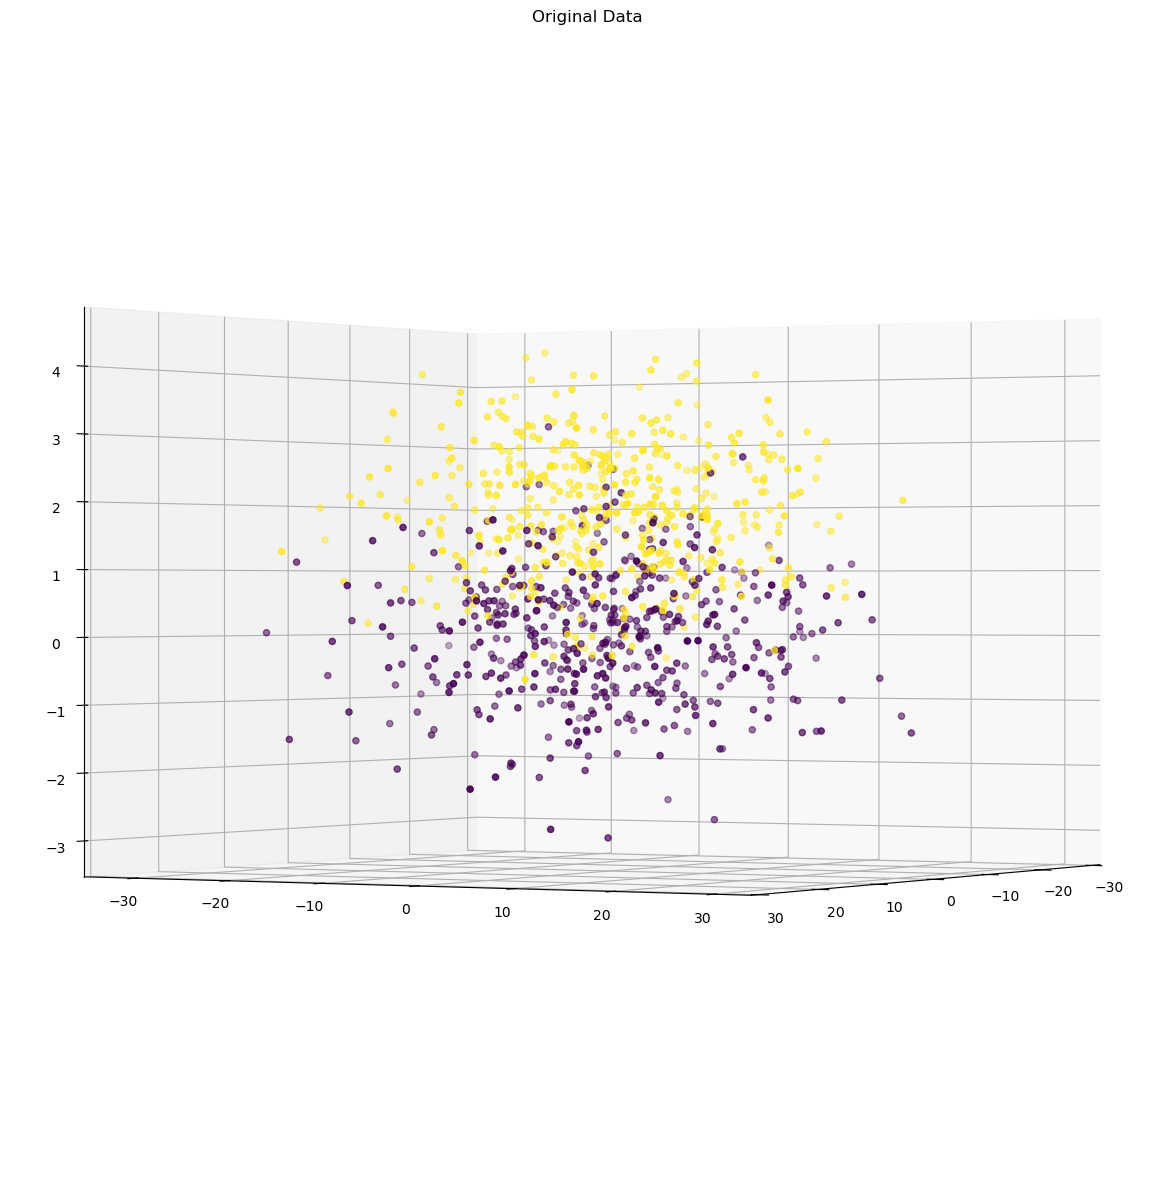

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


# Generate synthetic data
np.random.seed(0)
n_points = 500

# Class 0
x0 = np.random.normal(loc=0, scale=10, size=n_points)
y0 = np.random.normal(loc=0, scale=10, size=n_points)
z0 = np.random.normal(loc=0, scale=1, size=n_points)

# Class 1
x1 = np.random.normal(loc=0, scale=10, size=n_points)
y1 = np.random.normal(loc=0, scale=10, size=n_points)
z1 = np.random.normal(loc=2, scale=1, size=n_points)

X = np.vstack((np.hstack((x0, x1)), np.hstack((y0, y1)), np.hstack((z0, z1)))).T
y = np.hstack((np.zeros(n_points), np.ones(n_points)))

# Train KNN on original data
knn = KNeighborsClassifier()
knn.fit(X, y)
y_pred = knn.predict(X)
print(f"Original Data Accuracy: {accuracy_score(y, y_pred)}")

# Create a new figure
fig = plt.figure(figsize=(15,15))

# Add 3D subplot
# The format is (rows, columns, plot_number)
ax = fig.add_subplot(111, projection='3d')
ax.view_init(elev=0, azim=30)

ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=y, cmap='viridis')
ax.set_title('Original Data')

plt.show()

⭐ 1. How does KNN perform as the number of dimensions increases?
✔ In your original 3‑D dataset
KNN performs extremely well — nearly perfect accuracy.

Why?

The only meaningful separation is in the z‑dimension

Class 0: z ~ Normal(0, 1)

Class 1: z ~ Normal(2, 1)

x and y are just noise (wide Gaussian clouds)

KNN easily separates the classes because the z‑coordinate dominates the distance.

So in 3D, KNN is basically doing:

“Which point has a z‑value closer to mine?”

This works beautifully.

⭐ 2. Apply PCA that captures 90% of the variance — does it help?
✔ No — PCA actually hurts KNN here.
Here’s why:

🔹 PCA keeps the directions with the largest variance
In your dataset:

x and y have variance ≈ 100

z has variance ≈ 1

So PCA sees:

PC1 ≈ x

PC2 ≈ y

PC3 ≈ z (tiny variance)

To capture 90% variance, PCA keeps only PC1 and PC2.

🔥 That means PCA throws away the z‑dimension, which is the only dimension that separates the classes.
So after PCA:

The two classes become indistinguishable

KNN accuracy collapses to ~50% (random guessing)

✔ Why PCA fails
PCA assumes:

“Important structure = high variance directions”

But in your data:

“Important structure = low variance direction (z)”

So PCA destroys the signal.

⭐ 3. Does UMAP help?
✔ Yes — UMAP helps dramatically.
UMAP is nonlinear and preserves local neighborhoods, not variance.

UMAP will:

detect that points with similar z‑values cluster together

preserve the class separation

ignore the irrelevant x and y noise dimensions

UMAP effectively recovers the z‑axis separation, even though z has tiny variance.

| Method | Expected KNN Accuracy |
| --- | --- |
| Original 3D | ~100% |
| PCA (90% variance) | ~50% (fails) |
| UMAP | ~95–100% |

⭐ 4. What explains the difference?
✔ PCA is linear and variance‑based
Keeps high‑variance directions

Discards low‑variance directions

Fails when the class‑separating dimension has low variance

Cannot model nonlinear structure

✔ UMAP is nonlinear and neighborhood‑based
Preserves local relationships

Does not care about variance

Can detect subtle class‑separating structure

Handles nonlinear manifolds

✔ KNN is extremely sensitive to the geometry of the space
If PCA distorts the geometry → KNN collapses

If UMAP preserves neighborhoods → KNN thrives

| Step | What Happens | Why |
| --- | --- | --- |
| **Original 3D** | KNN ≈ perfect | z‑dimension separates classes |
| **PCA (90% variance)** | KNN ≈ random guessing | PCA discards z (low variance) |
| **UMAP** | KNN ≈ perfect | UMAP preserves neighborhood structure |